In [17]:
import sys
from pathlib import Path

cwd = Path.cwd()

if cwd.name == "notebooks":
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.analytics.returns import(
    cumulative_growth,
    total_return,
    annualized_return,
    rolling_return,
    drawdown,
    max_drawdown,
)

from src.analytics.volatility import (
    daily_volatility,
    annualized_volatility,
    rolling_volatility,
)

from src.analytics.correlation import (
    correlation_matrix,
    rolling_correlation,
)

from src.analytics.portfolio import (
    equal_weights,
    portfolio_simple_returns,
    portfolio_log_returns,
    portfolio_volatility,
    portfolio_covariance,
    sharpe_ratio,
)

pd.set_option(
    "display.max_columns",
    None,
)

pd.set_option(
    "display.float_format",
    lambda x: f"{x:.4f}",
)

print("Project root:", PROJECT_ROOT)
print("Imports successful.")

Project root: c:\Users\swaya\OneDrive\Documents\Multi-Asset-Market-Risk
Imports successful.


In [18]:
processed_dir = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

prices_path = (
    processed_dir
    / "prices.csv"
)

returns_path = (
    processed_dir
    / "returns.csv"
)

prices = pd.read_csv(
    prices_path,
    index_col=0,
    parse_dates=True,
)

returns = pd.read_csv(
    returns_path,
    index_col=0,
    parse_dates=True,
)

print(
    f"Prices shape: {prices.shape}"
)

print(
    f"Returns shape: {returns.shape}"
)

print(
    f"Price period: "
    f"{prices.index.min().date()} "
    f"to "
    f"{prices.index.max().date()}"
)

Prices shape: (5641, 3)
Returns shape: (5640, 3)
Price period: 2005-01-03 to 2026-09-04


In [19]:
expected_assets = {
    "SPY",
    "EURUSD",
    "TLT",
}

assert expected_assets.issubset(
    prices.columns
), "Missing asset(s) in prices."

assert expected_assets.issubset(
    returns.columns
), "Missing asset(s) in returns."

assert (
    prices.index.is_monotonic_increasing
), "Price dates are not sorted."

assert (
    returns.index.is_monotonic_increasing
), "Return dates are not sorted."

assert not prices.index.duplicated().any(), \
    "Duplicate dates in prices."

assert not returns.index.duplicated().any(), \
    "Duplicate dates in returns."

assert prices.isna().sum().sum() == 0, \
    "Prices contain missing values."

assert returns.isna().sum().sum() == 0, \
    "Returns contain missing values."

assert np.isfinite(
    returns.to_numpy()
).all(), \
    "Returns contain non-finite values."

print("All validation checks passed.")

All validation checks passed.


Total return:


,Total Return
SPY,8.4881
EURUSD,-0.1373
TLT,0.8806



Annualized return:


,Annualized Return
SPY,0.1058
EURUSD,-0.0066
TLT,0.0286


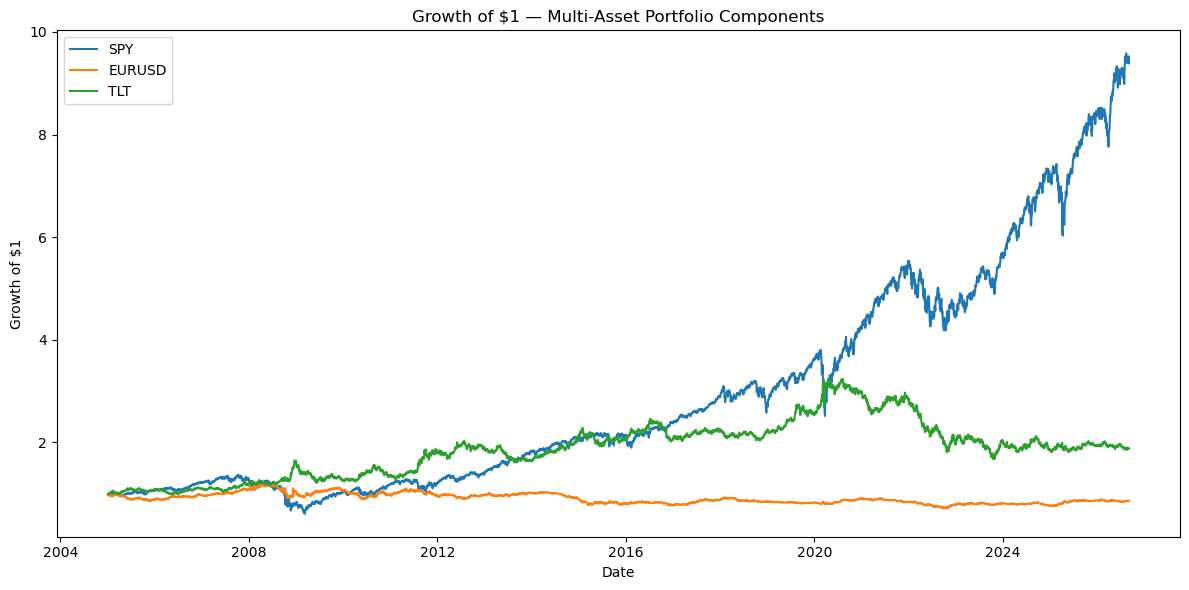

In [20]:
growth = cumulative_growth(
    returns
)

print("Total return:")
display(
    total_return(returns)
    .to_frame("Total Return")
)

print("\nAnnualized return:")
display(
    annualized_return(returns)
    .to_frame("Annualized Return")
)

plt.figure(figsize=(12, 6))

for column in growth.columns:
    plt.plot(
        growth.index,
        growth[column],
        label=column,
    )

plt.title(
    "Growth of $1 — Multi-Asset Portfolio Components"
)

plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()

plt.tight_layout()
plt.show()

Maximum drawdown:


,Maximum Drawdown
SPY,-0.5519
EURUSD,-0.3998
TLT,-0.4835


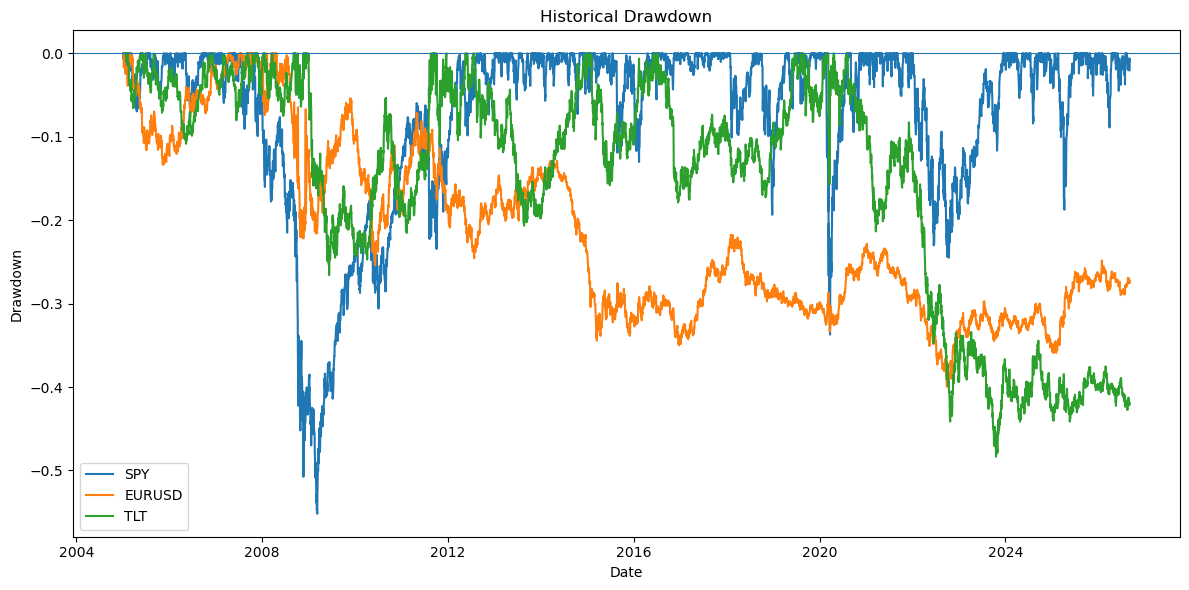

In [21]:
drawdowns = drawdown(
    growth
)

max_dd = max_drawdown(
    growth
)

print("Maximum drawdown:")
display(
    max_dd
    .to_frame("Maximum Drawdown")
)

plt.figure(figsize=(12, 6))

for column in drawdowns.columns:
    plt.plot(
        drawdowns.index,
        drawdowns[column],
        label=column,
    )

plt.axhline(
    0,
    linewidth=0.8,
)

plt.title(
    "Historical Drawdown"
)

plt.xlabel("Date")
plt.ylabel("Drawdown")

plt.legend()

plt.tight_layout()
plt.show()

In [22]:
daily_vol = daily_volatility(
    returns
)

annual_vol = annualized_volatility(
    returns
)

print("Daily volatility:")
display(
    daily_vol.to_frame(
        "Daily Volatility"
    )
)

print("\nAnnualized volatility:")
display(
    annual_vol.to_frame(
        "Annualized Volatility"
    )
)

Daily volatility:


,Daily Volatility
SPY,0.0117
EURUSD,0.0069
TLT,0.0090



Annualized volatility:


,Annualized Volatility
SPY,0.1858
EURUSD,0.1094
TLT,0.1430


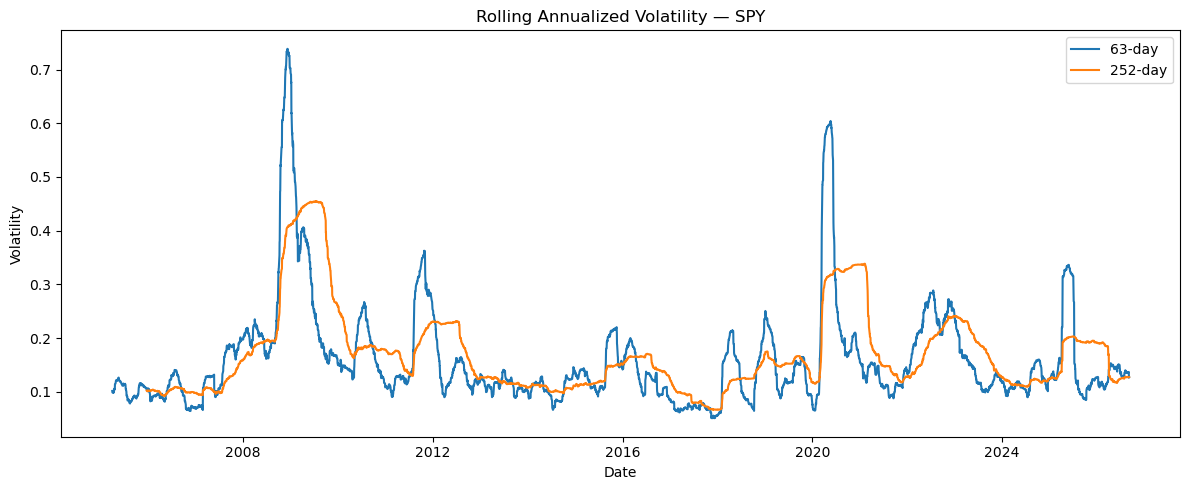

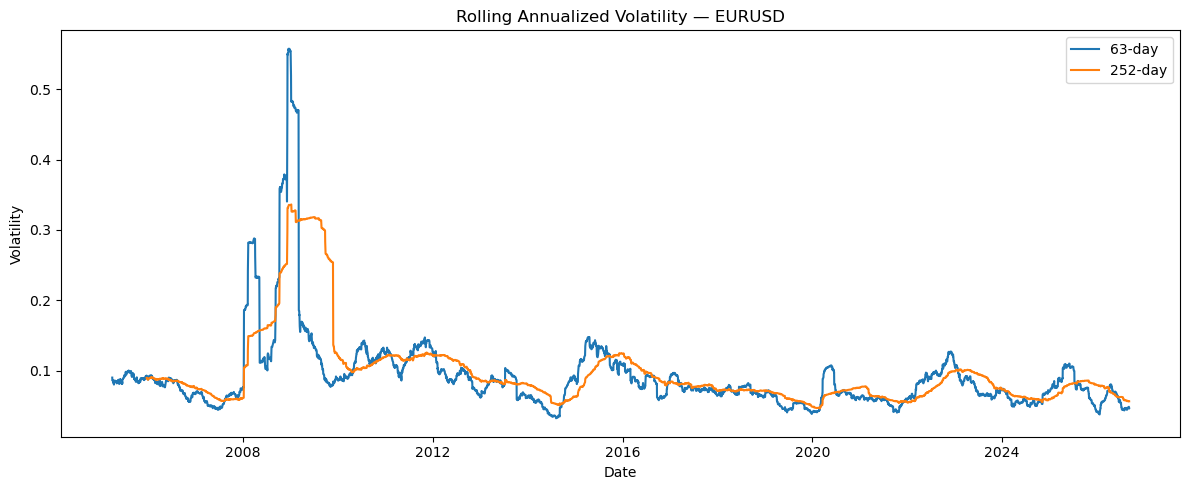

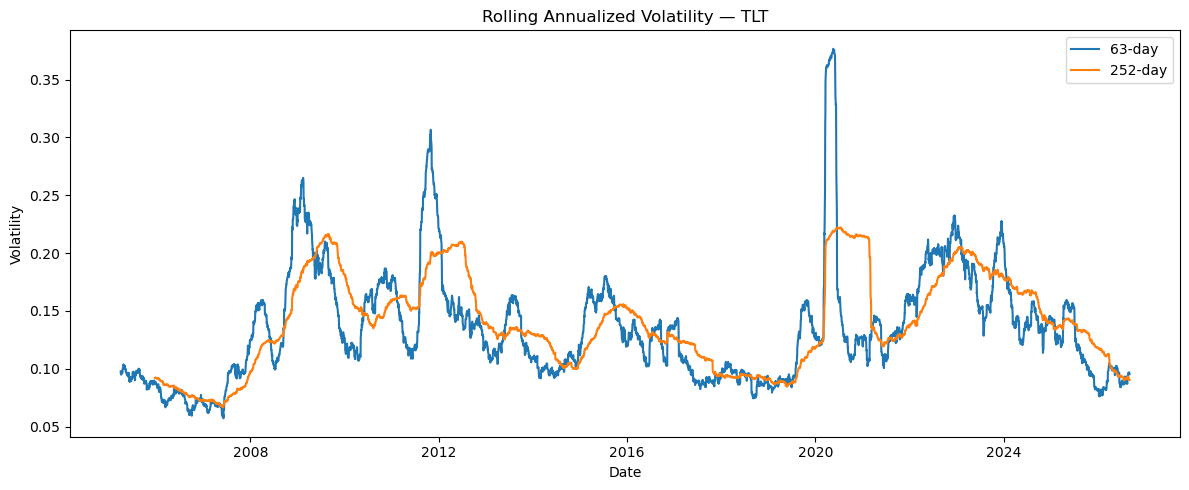

In [23]:
rolling_vol_63 = rolling_volatility(
    returns,
    window=63,
)

rolling_vol_252 = rolling_volatility(
    returns,
    window=252,
)

for column in returns.columns:

    plt.figure(figsize=(12, 5))

    plt.plot(
        rolling_vol_63.index,
        rolling_vol_63[column],
        label="63-day",
    )

    plt.plot(
        rolling_vol_252.index,
        rolling_vol_252[column],
        label="252-day",
    )

    plt.title(
        f"Rolling Annualized Volatility — {column}"
    )

    plt.xlabel("Date")
    plt.ylabel("Volatility")

    plt.legend()

    plt.tight_layout()
    plt.show()

Correlation matrix:


,SPY,EURUSD,TLT
SPY,1.0000,0.1217,-0.2973
EURUSD,0.1217,1.0000,-0.0201
TLT,-0.2973,-0.0201,1.0000


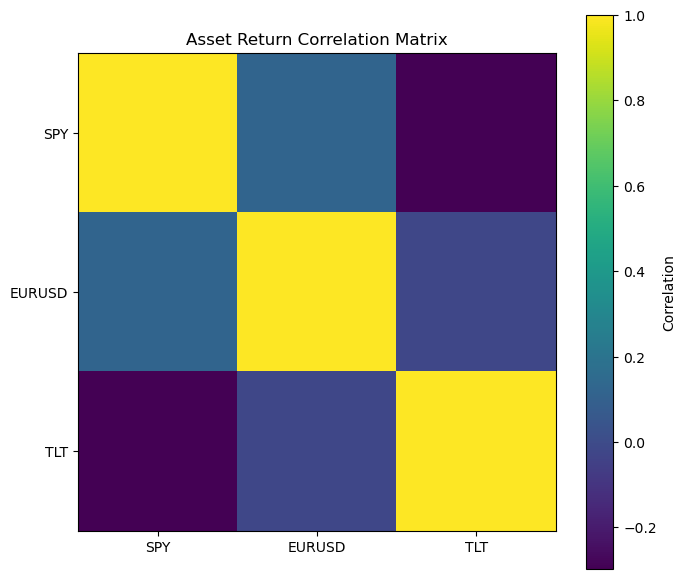

In [24]:
corr = correlation_matrix(
    returns
)

print("Correlation matrix:")
display(corr)

plt.figure(
    figsize=(7, 6)
)

plt.imshow(
    corr,
    interpolation="nearest",
)

plt.colorbar(
    label="Correlation"
)

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
)

plt.yticks(
    range(len(corr.index)),
    corr.index,
)

plt.title(
    "Asset Return Correlation Matrix"
)

plt.tight_layout()
plt.show()

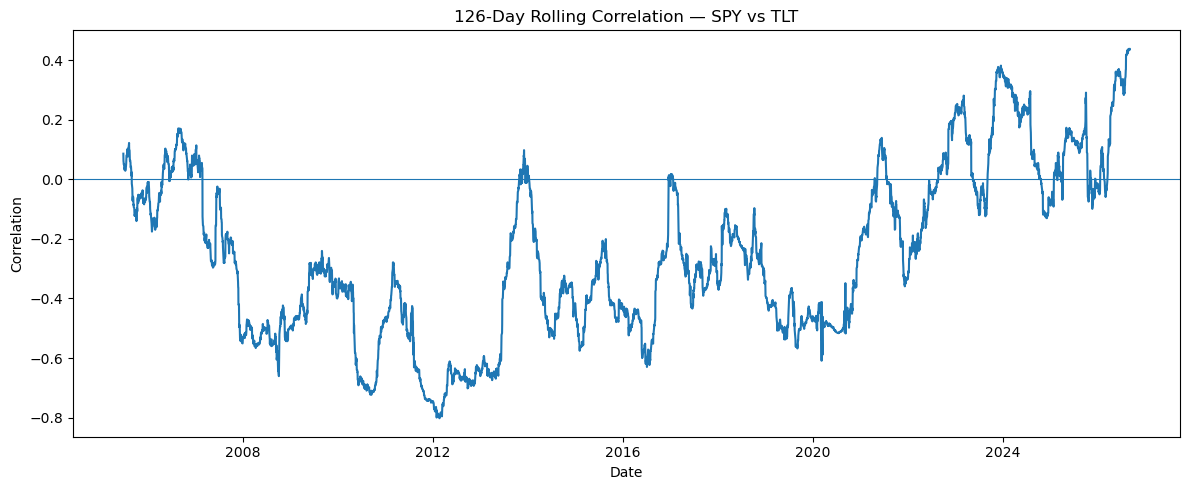

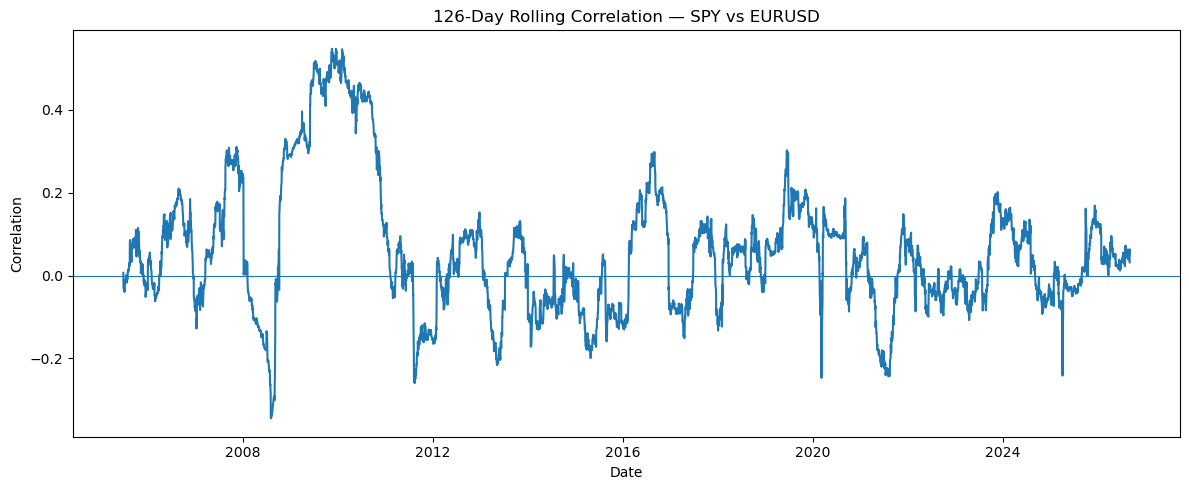

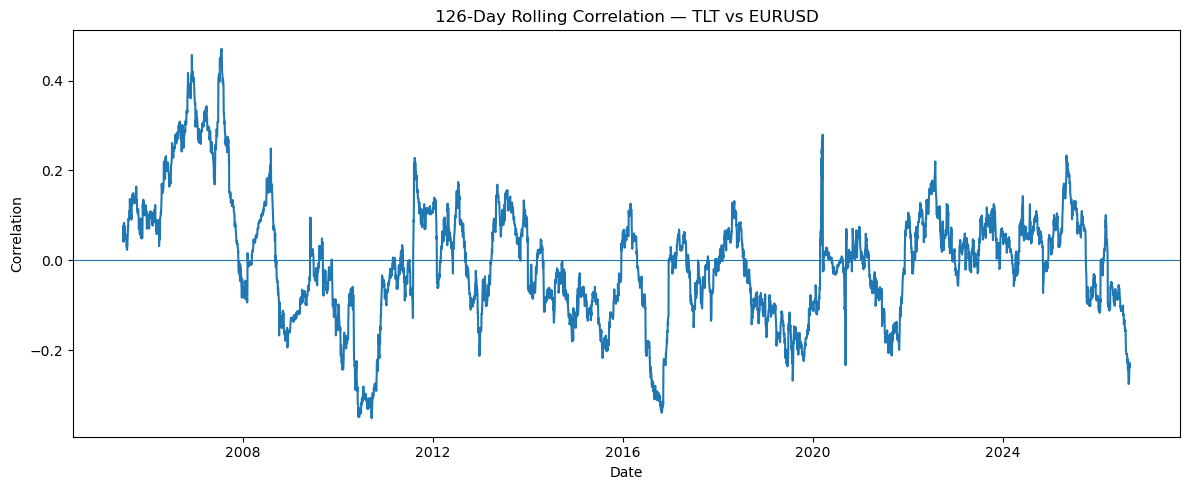

In [25]:
pairs = [
    ("SPY", "TLT"),
    ("SPY", "EURUSD"),
    ("TLT", "EURUSD"),
]

for asset_x, asset_y in pairs:

    rolling_corr = rolling_correlation(
        returns,
        asset_x,
        asset_y,
        window=126,
    )

    plt.figure(
        figsize=(12, 5)
    )

    plt.plot(
        rolling_corr.index,
        rolling_corr,
    )

    plt.axhline(
        0,
        linewidth=0.8,
    )

    plt.title(
        f"126-Day Rolling Correlation — "
        f"{asset_x} vs {asset_y}"
    )

    plt.xlabel("Date")
    plt.ylabel("Correlation")

    plt.tight_layout()
    plt.show()

In [26]:
weights = equal_weights(
    returns
)

print("Portfolio weights:")
display(
    weights.to_frame()
)

Portfolio weights:


,Weight
SPY,0.3333
EURUSD,0.3333
TLT,0.3333


In [27]:
portfolio_returns = (
    portfolio_simple_returns(
        returns,
        weights,
    )
)

portfolio_log = (
    portfolio_log_returns(
        returns,
        weights,
    )
)

print("Portfolio simple returns:")
display(
    portfolio_returns.head()
)

print("\nPortfolio log returns:")
display(
    portfolio_log.head()
)

Portfolio simple returns:


Date
2005-01-04   -0.0122
2005-01-05   -0.0006
2005-01-06   -0.0005
2005-01-07   -0.0028
2005-01-10    0.0034
Name: Portfolio, dtype: float64


Portfolio log returns:


Date
2005-01-04   -0.0123
2005-01-05   -0.0006
2005-01-06   -0.0005
2005-01-07   -0.0028
2005-01-10    0.0033
Name: Portfolio, dtype: float64

In [28]:
portfolio_variance = (
    portfolio_covariance(
        returns,
        weights,
    )
)

portfolio_vol = (
    portfolio_volatility(
        returns,
        weights,
    )
)

print(
    f"Annualized portfolio variance: "
    f"{portfolio_variance:.6f}"
)

print(
    f"Annualized portfolio volatility: "
    f"{portfolio_vol:.4%}"
)

Annualized portfolio variance: 0.006162
Annualized portfolio volatility: 7.8497%


In [29]:
portfolio_sharpe = sharpe_ratio(
    portfolio_returns,
    risk_free_rate_annual=0.0,
)

print(
    f"Annualized Sharpe ratio: "
    f"{portfolio_sharpe:.4f}"
)

Annualized Sharpe ratio: 0.6607


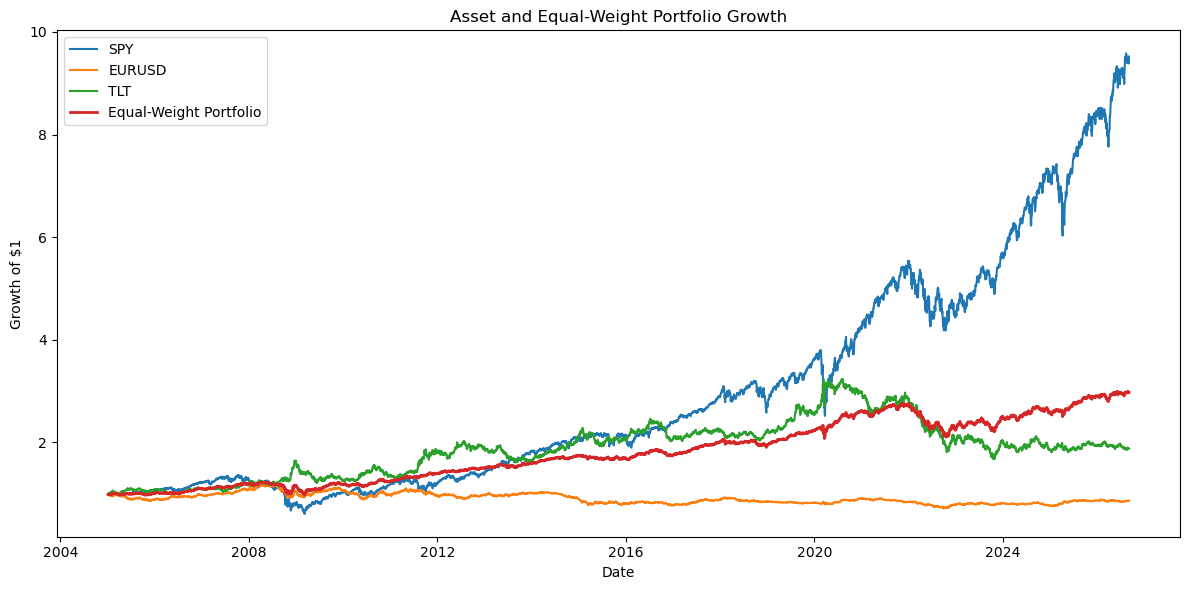

In [30]:
portfolio_growth = (
    (1 + portfolio_returns)
    .cumprod()
)

plt.figure(
    figsize=(12, 6)
)

for column in growth.columns:
    plt.plot(
        growth.index,
        growth[column],
        label=column,
    )

plt.plot(
    portfolio_growth.index,
    portfolio_growth,
    label="Equal-Weight Portfolio",
    linewidth=2,
)

plt.title(
    "Asset and Equal-Weight Portfolio Growth"
)

plt.xlabel("Date")
plt.ylabel("Growth of $1")

plt.legend()

plt.tight_layout()
plt.show()

In [31]:
summary = pd.DataFrame(
    {
        "Total Return": total_return(
            returns
        ),
        "Annualized Return": annualized_return(
            returns
        ),
        "Annualized Volatility": annualized_volatility(
            returns
        ),
        "Maximum Drawdown": max_drawdown(
            growth
        ),
    }
)

summary.loc[
    "Equal-Weight Portfolio",
    "Total Return",
] = (
    portfolio_returns.add(1)
    .prod()
    - 1
)

summary.loc[
    "Equal-Weight Portfolio",
    "Annualized Return",
] = (
    portfolio_returns.mean()
    * 252
)

summary.loc[
    "Equal-Weight Portfolio",
    "Annualized Volatility",
] = portfolio_vol

portfolio_growth_df = (
    portfolio_growth.to_frame(
        "Portfolio"
    )
)

portfolio_dd = drawdown(
    portfolio_growth_df
)

summary.loc[
    "Equal-Weight Portfolio",
    "Maximum Drawdown",
] = portfolio_dd.min().iloc[0]

display(summary)

,Total Return,Annualized Return,Annualized Volatility,Maximum Drawdown
SPY,8.4881,0.1058,0.1858,-0.5519
EURUSD,-0.1373,-0.0066,0.1094,-0.3998
TLT,0.8806,0.0286,0.1430,-0.4835
Equal-Weight Portfolio,1.9805,0.0519,0.0785,-0.2384


In [32]:
results_tables = (
    PROJECT_ROOT
    / "results"
    / "tables"
)

results_tables.mkdir(
    parents=True,
    exist_ok=True,
)

summary_path = (
    results_tables
    / "step8_portfolio_summary.csv"
)

summary.to_csv(
    summary_path
)

print(
    f"Saved portfolio summary to:\n"
    f"{summary_path}"
)

Saved portfolio summary to:
c:\Users\swaya\OneDrive\Documents\Multi-Asset-Market-Risk\results\tables\step8_portfolio_summary.csv
